### numpy  - для работы с массивами    имеет функции для работы в области линейной алгебры, преобразования Фурье и матриц


### начало

In [1]:
import numpy as np
arr = np.array([1, 2, 3, 4, 5])  # преобразовать массивоподобный объект в массив NumPy
print(arr)
print(type(arr))
print(np.__version__)




[1 2 3 4 5]
<class 'numpy.ndarray'>
1.26.1


In [2]:
arr0 = np.array(42)  # нульмерный массив
arr1 = np.array([1, 2, 3, 4, 5])  # одномерный массив
arr2 = np.array([[1, 2, 3], [4, 5, 6]]) # двумерный массив
# трёхмерный массив
arr3 = np.array([[[1, 2, 3], [4, 5, 6]], [[1, 2, 3], [4, 5, 6]]])

print(arr3.ndim)  # размерность массива

arr5 = np.array([1, 2, 3, 4], ndmin=5) # создать массив опред размерности 
print(arr5.ndim)

print()
print(arr3[0, 1, 2]) #  доступ к элементам
print(arr1[1:5:2])  # срез как в списках
print(arr3[1, 1, :2])  # срез н/р в трёхмерном массиве

# необычно!  срез в двумерном массиве и обращение здесь 3  к каждому элементу среза
arr = np.array([[1, 2, 3, 4, 5], [6, 7, 8, 9, 10], [1, 2, 3, 4, 5]])
print(arr[0:3, 3])   # [4, 9, 4]
print(arr[0:2, 1:4])


3
5

6
[2 4]
[4 5]
[4 9 4]
[[2 3 4]
 [7 8 9]]


In [3]:
arr = np.array(['apple', 'banana', 'cherry'])
print(arr.dtype)  # тип numpy
arr = np.array([1, 2, 3, 4], dtype='S')  # назначить тип   (каждому эл-ту?)
print(arr.dtype)  

arr = np.array([1.1, 2.1, 3.1])
newarr = arr.astype('i')         # изменить тип 
print(newarr)


<U6
|S1
[1 2 3]


In [4]:
arr = np.array([[1, 2, 3, 4], [5, 6, 7, 8]])
print(arr.shape)  # форма массива (кортеж из числа эл-тов в каждом измерении)   (2,4)


arr = np.array([1, 2, 3, 4], ndmin=5)
print(arr)
print('shape of array :', arr.shape)


arr = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
newarr = arr.reshape(3, 4)  # изменить форму (размерность) 
arr[11] = 0
print(newarr) # форма изменилась  но зависимость осталась


arr = np.array([1, 2, 3, 4, 5, 6, 7, 8])
newarr = arr.reshape(2, 2, -1)  # -1 если неизвестное (пусть считает автоматом)
print(newarr)

print('_________')
arr = np.array([[1, 2, 3], [4, 5, 6]])
newarr = arr.reshape(-1)      # сделать одномерным 
print(newarr)
## другие методы для изменения формы ...  flatten ravel rot90 flip fliplr flipud


(2, 4)
[[[[[1 2 3 4]]]]]
shape of array : (1, 1, 1, 1, 4)
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11  0]]
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
_________
[1 2 3 4 5 6]


In [5]:
# циклы
arr = np.array([[[1, 2], [4, 5]], [[7, 8], [10, 11]]])
'''
for x in arr:
  for y in x:
    for z in y:
      print(z)
'''
for x in np.nditer(arr):   # позволяет обойтись без вложенных циклов 
  print(x)


arr = np.array([[1, 2, 3, 4], [5, 6, 7, 8]])
for idx, x in np.ndenumerate(arr):      # многомерный вариант метода  enumerate
  print(idx, x)


1
2
4
5
7
8
10
11
(0, 0) 1
(0, 1) 2
(0, 2) 3
(0, 3) 4
(1, 0) 5
(1, 1) 6
(1, 2) 7
(1, 3) 8


In [6]:
s = np.array([1, 2, 3])
d = np.array([4, 5, 6])
# (сложение ((прямое)) массивов    отличается от python  (поэлементно +, -, *, ... ))
print(s + d + d + d)
print(np.add(s,d))

# сложение ((слияние)) (как в py) массивов
arr = np.concatenate((s, d, s, s))  
print(arr)

arr1 = np.array([[[[1, 2], [3, 4]], [[5, 6], [7, 8]]], [[[5, 6], [7, 8]], [[1, 2], [3, 4]]]])
arr2 = np.array([[[[11, 12], [13,33]], [[14, 15], [16, 66]]], [[[21, 22], [23, 77]], [[24, 25], [26, 88]]]])
arr = np.concatenate((arr1, arr2), axis=2)
print(arr)

# сложение ((объединение)) массивов  (+1 измерение)
print('-------------')
arr1 = np.array([1, 2, 3])
arr2 = np.array([4, 5, 6])
arr = np.stack((arr1, arr2), axis=1)
print(arr)


[13 17 21]
[5 7 9]
[1 2 3 4 5 6 1 2 3 1 2 3]
[[[[ 1  2]
   [ 3  4]
   [11 12]
   [13 33]]

  [[ 5  6]
   [ 7  8]
   [14 15]
   [16 66]]]


 [[[ 5  6]
   [ 7  8]
   [21 22]
   [23 77]]

  [[ 1  2]
   [ 3  4]
   [24 25]
   [26 88]]]]
-------------
[[1 4]
 [2 5]
 [3 6]]


### _______ для сравнения  (удалить?)

In [7]:
arr1 = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
arr2 = np.array([[[9, 10], [11, 12]], [[13, 14], [15, 16]]])

arr = np.concatenate((arr1, arr2))
print(arr)
print('-----------')
arr = np.concatenate((arr1, arr2), axis=1)
print(arr)
print('-----------')
arr = np.concatenate((arr1, arr2), axis=2)
print(arr)

# [[[ 1  2][ 3  4]]  [[ 5  6][ 7  8]]  [[ 9 10][11 12]]  [[13 14][15 16]]]   (4, 2, 2)
#     [[[ 1  2][ 3  4][ 9 10][11 12]]  [[ 5  6][ 7  8][13 14][15 16]]]       (2, 4, 2)
#       [[[ 1  2  9 10][ 3  4 11 12]]  [[ 5  6 13 14][ 7  8 15 16]]]         (2, 2, 4) 


[[[ 1  2]
  [ 3  4]]

 [[ 5  6]
  [ 7  8]]

 [[ 9 10]
  [11 12]]

 [[13 14]
  [15 16]]]
-----------
[[[ 1  2]
  [ 3  4]
  [ 9 10]
  [11 12]]

 [[ 5  6]
  [ 7  8]
  [13 14]
  [15 16]]]
-----------
[[[ 1  2  9 10]
  [ 3  4 11 12]]

 [[ 5  6 13 14]
  [ 7  8 15 16]]]


In [8]:
arr = np.stack((arr1, arr2))
print(arr)
print('-----------')
arr = np.stack((arr1, arr2), axis=1)
print(arr)
print('-----------')
arr = np.stack((arr1, arr2), axis=2)
print(arr)
print('-----------')
arr = np.stack((arr1, arr2), axis=3)
print(arr)

# [[[[ 1  2][ 3  4]]  [[ 5  6][ 7  8]]]   [[[ 9 10][11 12]]  [[13 14][15 16]]]] 
# [[[[ 1  2][ 3  4]]  [[ 9 10][11 12]]]   [[[ 5  6][ 7  8]]  [[13 14][15 16]]]]
# [[[[ 1  2][ 9 10]]  [[ 3  4][11 12]]]   [[[ 5  6][13 14]]  [[ 7  8][15 16]]]]
# [[[[ 1  9][ 2 10]]  [[ 3 11][ 4 12]]]   [[[ 5 13][ 6 14]]  [[ 7 15][ 8 16]]]]


[[[[ 1  2]
   [ 3  4]]

  [[ 5  6]
   [ 7  8]]]


 [[[ 9 10]
   [11 12]]

  [[13 14]
   [15 16]]]]
-----------
[[[[ 1  2]
   [ 3  4]]

  [[ 9 10]
   [11 12]]]


 [[[ 5  6]
   [ 7  8]]

  [[13 14]
   [15 16]]]]
-----------
[[[[ 1  2]
   [ 9 10]]

  [[ 3  4]
   [11 12]]]


 [[[ 5  6]
   [13 14]]

  [[ 7  8]
   [15 16]]]]
-----------
[[[[ 1  9]
   [ 2 10]]

  [[ 3 11]
   [ 4 12]]]


 [[[ 5 13]
   [ 6 14]]

  [[ 7 15]
   [ 8 16]]]]


In [9]:
arr = np.hstack((arr1, arr2))
print(arr)
print('-----------')
arr = np.vstack((arr1, arr2))
print(arr)
print('-----------')
arr = np.dstack((arr1, arr2))
print(arr) 

#      [[[ 1  2][ 3  4][ 9 10][11 12]]  [[ 5  6][ 7  8][13 14][15 16]]]
#  [[[ 1  2][ 3  4]]  [[ 5  6][ 7  8]]  [[ 9 10][11 12]]  [[13 14][15 16]]]
#        [[[ 1  2  9 10][ 3  4 11 12]]  [[ 5  6 13 14][ 7  8 15 16]]]


[[[ 1  2]
  [ 3  4]
  [ 9 10]
  [11 12]]

 [[ 5  6]
  [ 7  8]
  [13 14]
  [15 16]]]
-----------
[[[ 1  2]
  [ 3  4]]

 [[ 5  6]
  [ 7  8]]

 [[ 9 10]
  [11 12]]

 [[13 14]
  [15 16]]]
-----------
[[[ 1  2  9 10]
  [ 3  4 11 12]]

 [[ 5  6 13 14]
  [ 7  8 15 16]]]


###  далее 

In [10]:
arr = np.array([1, 2, 3, 4, 5, 6])
newarr = np.array_split(arr, 4) # разделение массива на (по возможности) равные части (в списке)
# newarr = np.split(arr, 3)   # разделение массива (если не делится нацело - ошибка)
print(newarr)

arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [13, 14, 15], [16, 17, 18]])
newarr = np.array_split(arr, 3)
print(newarr)

arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [13, 14, 15], [16, 17, 18]])
newarr = np.array_split(arr, 3, axis=1)
print(newarr)

# ещё   .hsplit(arr, 3)   vsplit()   dsplit()   ((тоже что array_split  по осям  ??))


[array([1, 2]), array([3, 4]), array([5]), array([6])]
[array([[1, 2, 3],
       [4, 5, 6]]), array([[ 7,  8,  9],
       [10, 11, 12]]), array([[13, 14, 15],
       [16, 17, 18]])]
[array([[ 1],
       [ 4],
       [ 7],
       [10],
       [13],
       [16]]), array([[ 2],
       [ 5],
       [ 8],
       [11],
       [14],
       [17]]), array([[ 3],
       [ 6],
       [ 9],
       [12],
       [15],
       [18]])]


In [11]:
arr = np.array([1, 2, 3, 4, 5, 4, 4])
x = np.where(arr == 4) # поиск  -> массив позиций соответствующих условию ?
print(x)

arr = np.array([1, 2, 3, 4, 5, 6, 7, 8])
x = np.where(arr % 2 == 0)    # где чётные
print(x)

arr = np.array([6, 7, 8, 9])
x = np.searchsorted(arr, 7, side='right') # поиск позиция чтобы сохранилась сортировка
print(x)
arr = np.array([1, 3, 5, 7])
x = np.searchsorted(arr, [2, 4, 6]) #  тоже несколько 
print(x)


(array([3, 5, 6], dtype=int64),)
(array([1, 3, 5, 7], dtype=int64),)
2
[1 2 3]


In [12]:
# сортировка 
arr = np.array([[3, 2, 4], [5, 0, 1]])
print(np.sort(arr)) 
#  -->  отсортированную (по всем подмассивам) копию (а sort py меняет сам список )

# фильтр (маска )
arr = np.array([41, 42, 43, 44])
x = arr[[True, False, True, False]]
print(x)

# маску можно создать циклом 
filter_arr = []
for element in arr:
    if element > 42:
        filter_arr.append(True)
    else:
        filter_arr.append(False)

newarr = arr[filter_arr]
print(filter_arr)
print(newarr)

#  но можно проще 
filter_arr = arr > 42   # др пример filter_arr = arr % 2 == 0 (только чётные)
newarr = arr[filter_arr]
print(filter_arr)
print(newarr)

arr = np.array([[3, 2, 4], [5, 0, 1]])  # можно многомерный массив
print(arr[arr > 2])  # --> [3 4 5]


[[2 3 4]
 [0 1 5]]
[41 43]
[False, False, True, True]
[43 44]
[False False  True  True]
[43 44]
[3 4 5]


###  randon np

In [13]:
from numpy import random

x = random.randint(100)          # случайное целое число до н/р 100
print(x)
x = random.randint(100, size=5)  # массив н/р 5-и случайных целых чисел   н/р до 100
print(x)
x = random.randint(100, size=(3, 5)) # тоже многомерный массив
print(x)

x = random.rand()       # случайное float ?  от 0 ло 1
print(x)
x = random.rand(5)      # массив н/р 5-и случайных float ? чисел    от 0 ло 1
print(x)
x = random.rand(3, 5)   # тоже многомерный массив
print(x)

x = random.choice([3, 5, 7, 9])  # случайный выбор из списка
print(x)
x = random.choice([3, 5, 7, 9], size=5)        # тоже в виде массива  
print(x)
x = random.choice([3, 5, 7, 9], size=(3, 5))   # тоже в виде многомерного массива
print(x)

print('---------------')
# тоже с распределением (вероятностями выпадения (весами))
x = random.choice([3, 5, 7, 9], p=[0.1, 0.3, 0.6, 0.0])
print(x)
x = random.choice([3, 5, 7, 9], p=[0.1, 0.3, 0.6, 0.0], size=(100))
print(x)
# Сумма всех p (вероятностных чисел) должна быть равна 1.
x = random.choice([3, 5, 7, 9], p=[0.1, 0.3, 0.6, 0.0], size=(3, 5))
print(x)


arr = np.array([1, 2, 3, 4, 5])
print(random.permutation(arr))  # исходный массив НЕ изменяется
random.shuffle(arr)             # исходный массив    изменяется
print(arr)



12
[97 83 91  9 13]
[[15 64 21 80 51]
 [90 61 44 19 74]
 [63 13 69 57  9]]
0.903382983497277
[0.37648162 0.9200209  0.19452016 0.57604905 0.30697082]
[[0.79650557 0.96313132 0.76610891 0.95584538 0.82287991]
 [0.66010842 0.85370911 0.1219929  0.45754323 0.26601651]
 [0.49203461 0.40781151 0.38747272 0.63174929 0.01706897]]
5
[9 5 7 5 7]
[[5 3 5 5 7]
 [5 7 5 7 5]
 [7 9 7 3 9]]
---------------
7
[7 7 5 5 5 7 5 7 7 3 7 7 5 7 5 3 7 7 3 7 5 5 7 7 7 7 3 3 5 7 7 3 7 7 7 7 5
 7 7 5 7 7 7 7 7 7 7 7 7 7 5 7 7 5 7 5 5 5 7 5 7 7 7 5 7 5 7 7 5 7 7 7 7 3
 7 7 3 7 5 5 7 7 7 5 7 7 7 7 7 5 7 3 7 7 5 7 7 7 7 7]
[[7 7 5 7 5]
 [7 7 7 7 7]
 [7 7 7 7 5]]
[1 5 4 2 3]
[1 4 2 5 3]


[[ 1.27299012 -0.16188356  1.67555739]
 [-0.19195206  0.25657994 -1.2994746 ]]
[[ 1.60367272  3.03293768  3.84789372]
 [-0.27671792 -0.61848046 -2.71503253]]
[4.08228135 5.55463868 5.321846   ... 7.29330547 4.50188512 3.6420855 ]


C:\Users\Odins\AppData\Local\Temp\ipykernel_16488\3729330971.py:14: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(random.normal(loc=5, scale=2, size=(10000))) #, hist=False график без гистограммы
C:\Users\Odins\AppData\Local\Temp\ipykernel_16488\3729330971.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

 

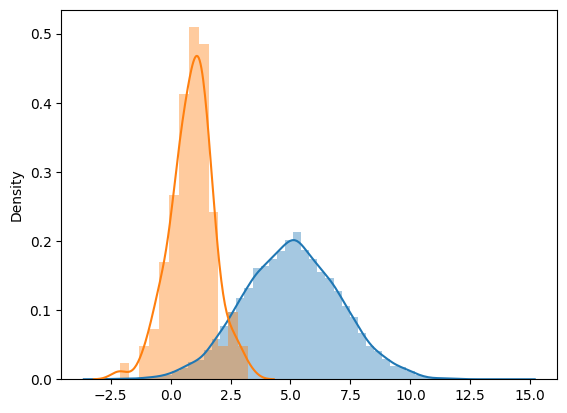

C:\Users\Odins\AppData\Local\Temp\ipykernel_16488\3729330971.py:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(random.binomial(n=100, p=0.5, size=1000))


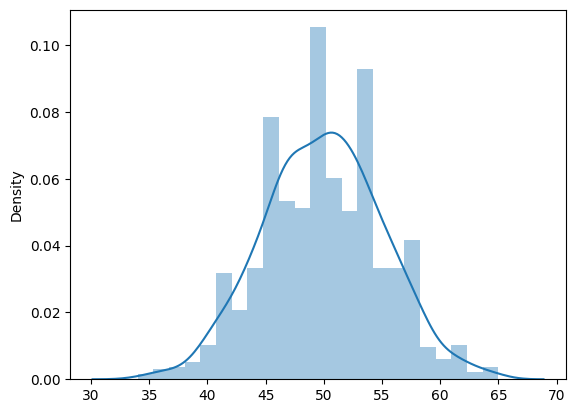

C:\Users\Odins\AppData\Local\Temp\ipykernel_16488\3729330971.py:22: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(random.poisson(lam=2, size=1000))
C:\Users\Odins\AppData\Local\Temp\ipykernel_16488\3729330971.py:24: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(random.uniform(size=1000))


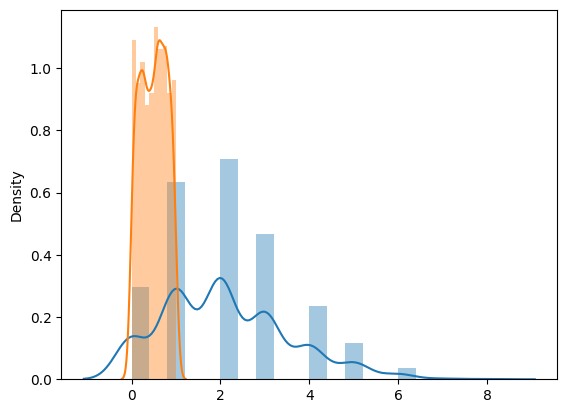

In [17]:
from numpy import random
import matplotlib.pyplot as plt
import seaborn as sns

x = random.normal(size=(2, 3)) # нормальное распред (гаусса) 
print(x)
x = random.normal(loc=1, scale=2, size=(2, 3)) 
# тоже со средним значением loc и стандартным отклонением scale
print(x)


# distplot  УСТАРЕЛО ??
sns.distplot(random.normal(loc=5, scale=2, size=(10000))) #, hist=False график без гистограммы 
sns.distplot(random.normal(loc=1, scale=1, size=(100)))   #, kde=False  гистограмма без графика
plt.show()

# биноминальное распред (здесь подброс монеты)
sns.distplot(random.binomial(n=100, p=0.5, size=1000)) 
plt.show()  
# распред пуассона
sns.distplot(random.poisson(lam=2, size=1000))
# равномерное распределение
sns.distplot(random.uniform(size=1000))
plt.show()

C:\Users\Odins\AppData\Local\Temp\ipykernel_16488\2607904864.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(random.exponential(size=1000), hist=False) # экспоненциальное распред


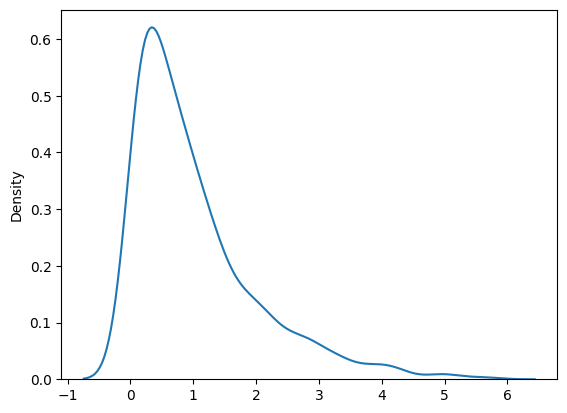

C:\Users\Odins\AppData\Local\Temp\ipykernel_16488\2607904864.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(random.pareto(a=2, size=1000), kde=False)


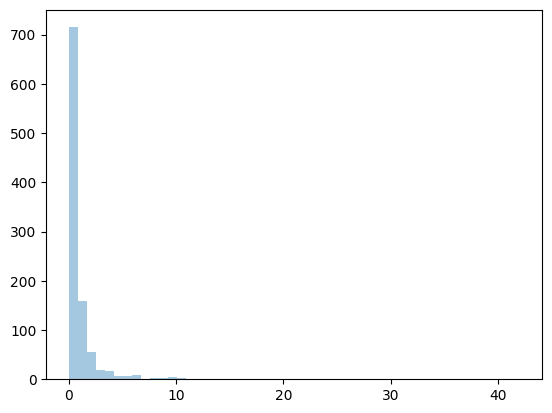

C:\Users\Odins\AppData\Local\Temp\ipykernel_16488\2607904864.py:20: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x[x < 10], kde=False)


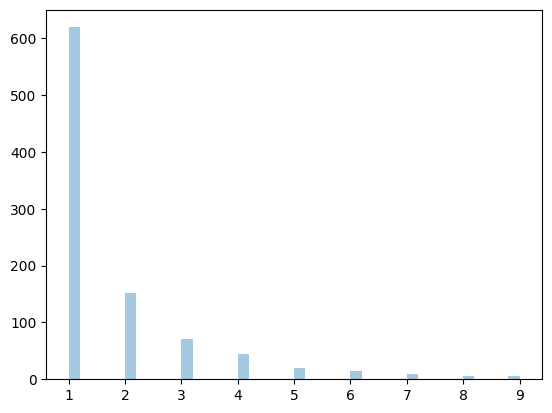

In [15]:
# (логистическое распределение)
x = random.logistic(loc=1, scale=2, size=(2, 3))

# (мультиноминальное распределение) (см биноминальное)
x = random.multinomial(n=6, pvals=[1/6, 1/6, 1/6, 1/6, 1/6, 1/6]) # бросание кубика

sns.distplot(random.exponential(size=1000), hist=False) # экспоненциальное распред
plt.show()


x = random.chisquare(df=2, size=(2, 3))   # распределение хи-квадрат  df степень свободы
x = random.rayleigh(scale=2, size=(2, 3))  # распределение рейли (частный случай хи-квадрат ?)

# распределение по закону Парето, т.е. распределение 80 на 20 (20% факторов обуславливают 80% результата).
sns.distplot(random.pareto(a=2, size=1000), kde=False)
plt.show()

# Распределения Ципфа          Закон Ципфа: В коллекции n-й общий член в 1/n раз больше самого общеупотребительного члена. Например, 5-е по распространенности слово в английском языке встречается почти в 1/5 раза чаще, чем Самое распространенное слово.
x = random.zipf(a=2, size=1000)
sns.distplot(x[x < 10], kde=False)
plt.show()


In [20]:
x = random.normal(5.0, 1.0, 1000)
print(x)

[5.95458088 3.82227731 4.49437116 4.30596137 4.21887974 5.40875687
 5.53470551 4.43214887 4.66073809 5.26533881 5.47751732 3.84010185
 5.12226828 4.09632847 5.34803283 4.01340411 6.03506208 5.47545822
 5.37964765 5.93036716 5.31988386 4.25205735 5.53771382 4.34731866
 5.71185766 3.01678022 4.45192235 4.65943399 4.94567632 3.86507099
 6.59740093 6.32883947 5.29672471 6.29908396 2.89416567 4.70621028
 5.66981841 5.80515568 6.05880624 5.64408553 5.51779648 4.39150684
 6.70200788 7.05626429 6.56976364 5.10383202 7.59324176 5.08358313
 5.6693385  6.38763799 5.60188223 3.79260868 3.98512488 3.59534752
 6.47977204 5.7961685  4.48059647 6.70349251 6.28925524 4.03605199
 5.30252602 6.786278   7.7561373  4.76391986 5.11620607 5.97830855
 5.47595311 4.33414464 6.43851722 5.30078045 4.73362486 5.82246109
 4.04935406 4.86379722 4.89726645 3.8883955  3.37447927 6.31405459
 5.20614304 6.72058908 4.90880513 6.01246319 4.24812749 3.55803982
 5.21857169 6.74396027 6.05269352 2.93465873 5.29042538 6.0000

In [9]:
from math import factorial
rez = factorial(365)/factorial(362) /365 ** 3
print(rez)

rez1 = (factorial(366)/factorial(363)) / ((366 ** 3)) 
print(rez1)

print(rez1/(rez))

print((factorial(366)/factorial(323))/(factorial(365)/factorial(322)))
print((366 ** 43)/(365 ** 43))  

0.9917958341152187
0.9918182089641375
1.0000225599343628
1.13312693498452
1.1248471190133962


In [2]:
print(1/366)
print(((6/(5*366)) ** 2) * 183 + ((4/(5*366)) ** 2) * 183)

0.00273224043715847
0.0028415300546448087
